In [2]:
import os
import pickle as pkl

from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats
from pydeseq2.utils import load_example_data

SAVE = False  # whether to save the outputs of this notebook

if SAVE:
    # Replace this with the path to directory where you would like results to be saved
    OUTPUT_PATH = "./data"
    os.makedirs(OUTPUT_PATH, exist_ok=True)  # Create path if it doesn't exist

In [3]:
import pandas as pd
import numpy as np

In [4]:
DGE_res = pd.read_pickle('./data/ds.pkl')

Running Wald tests...


... done in 2.96 seconds.



Log2 fold change & Wald test p-value: condition F vs M
              baseMean  log2FoldChange     lfcSE      stat        pvalue  \
A1BG       3711.892052        0.927279  0.119990  0.000000  1.000000e+00   
A1BG-AS1     98.694856       -0.750802  0.104634  0.000000  1.000000e+00   
A1CF       7198.748119        0.176266  0.126319  0.000000  1.000000e+00   
A2M       40815.349880        0.685654  0.101454  0.000000  1.000000e+00   
A2M-AS1     181.095061        0.789444  0.123562  0.000000  1.000000e+00   
...                ...             ...       ...       ...           ...   
ZYG11A       98.008879        0.374990  0.086490  0.000000  1.000000e+00   
ZYG11B     1646.148674       -0.092298  0.075289  0.000000  1.000000e+00   
ZYX        1375.247744       -1.507344  0.096100 -5.279311  1.296703e-07   
ZZEF1      2233.812057        0.027240  0.074976  0.000000  1.000000e+00   
ZZZ3       1093.916593       -0.013389  0.061602  0.000000  1.000000e+00   

              padj  
A1BG      1

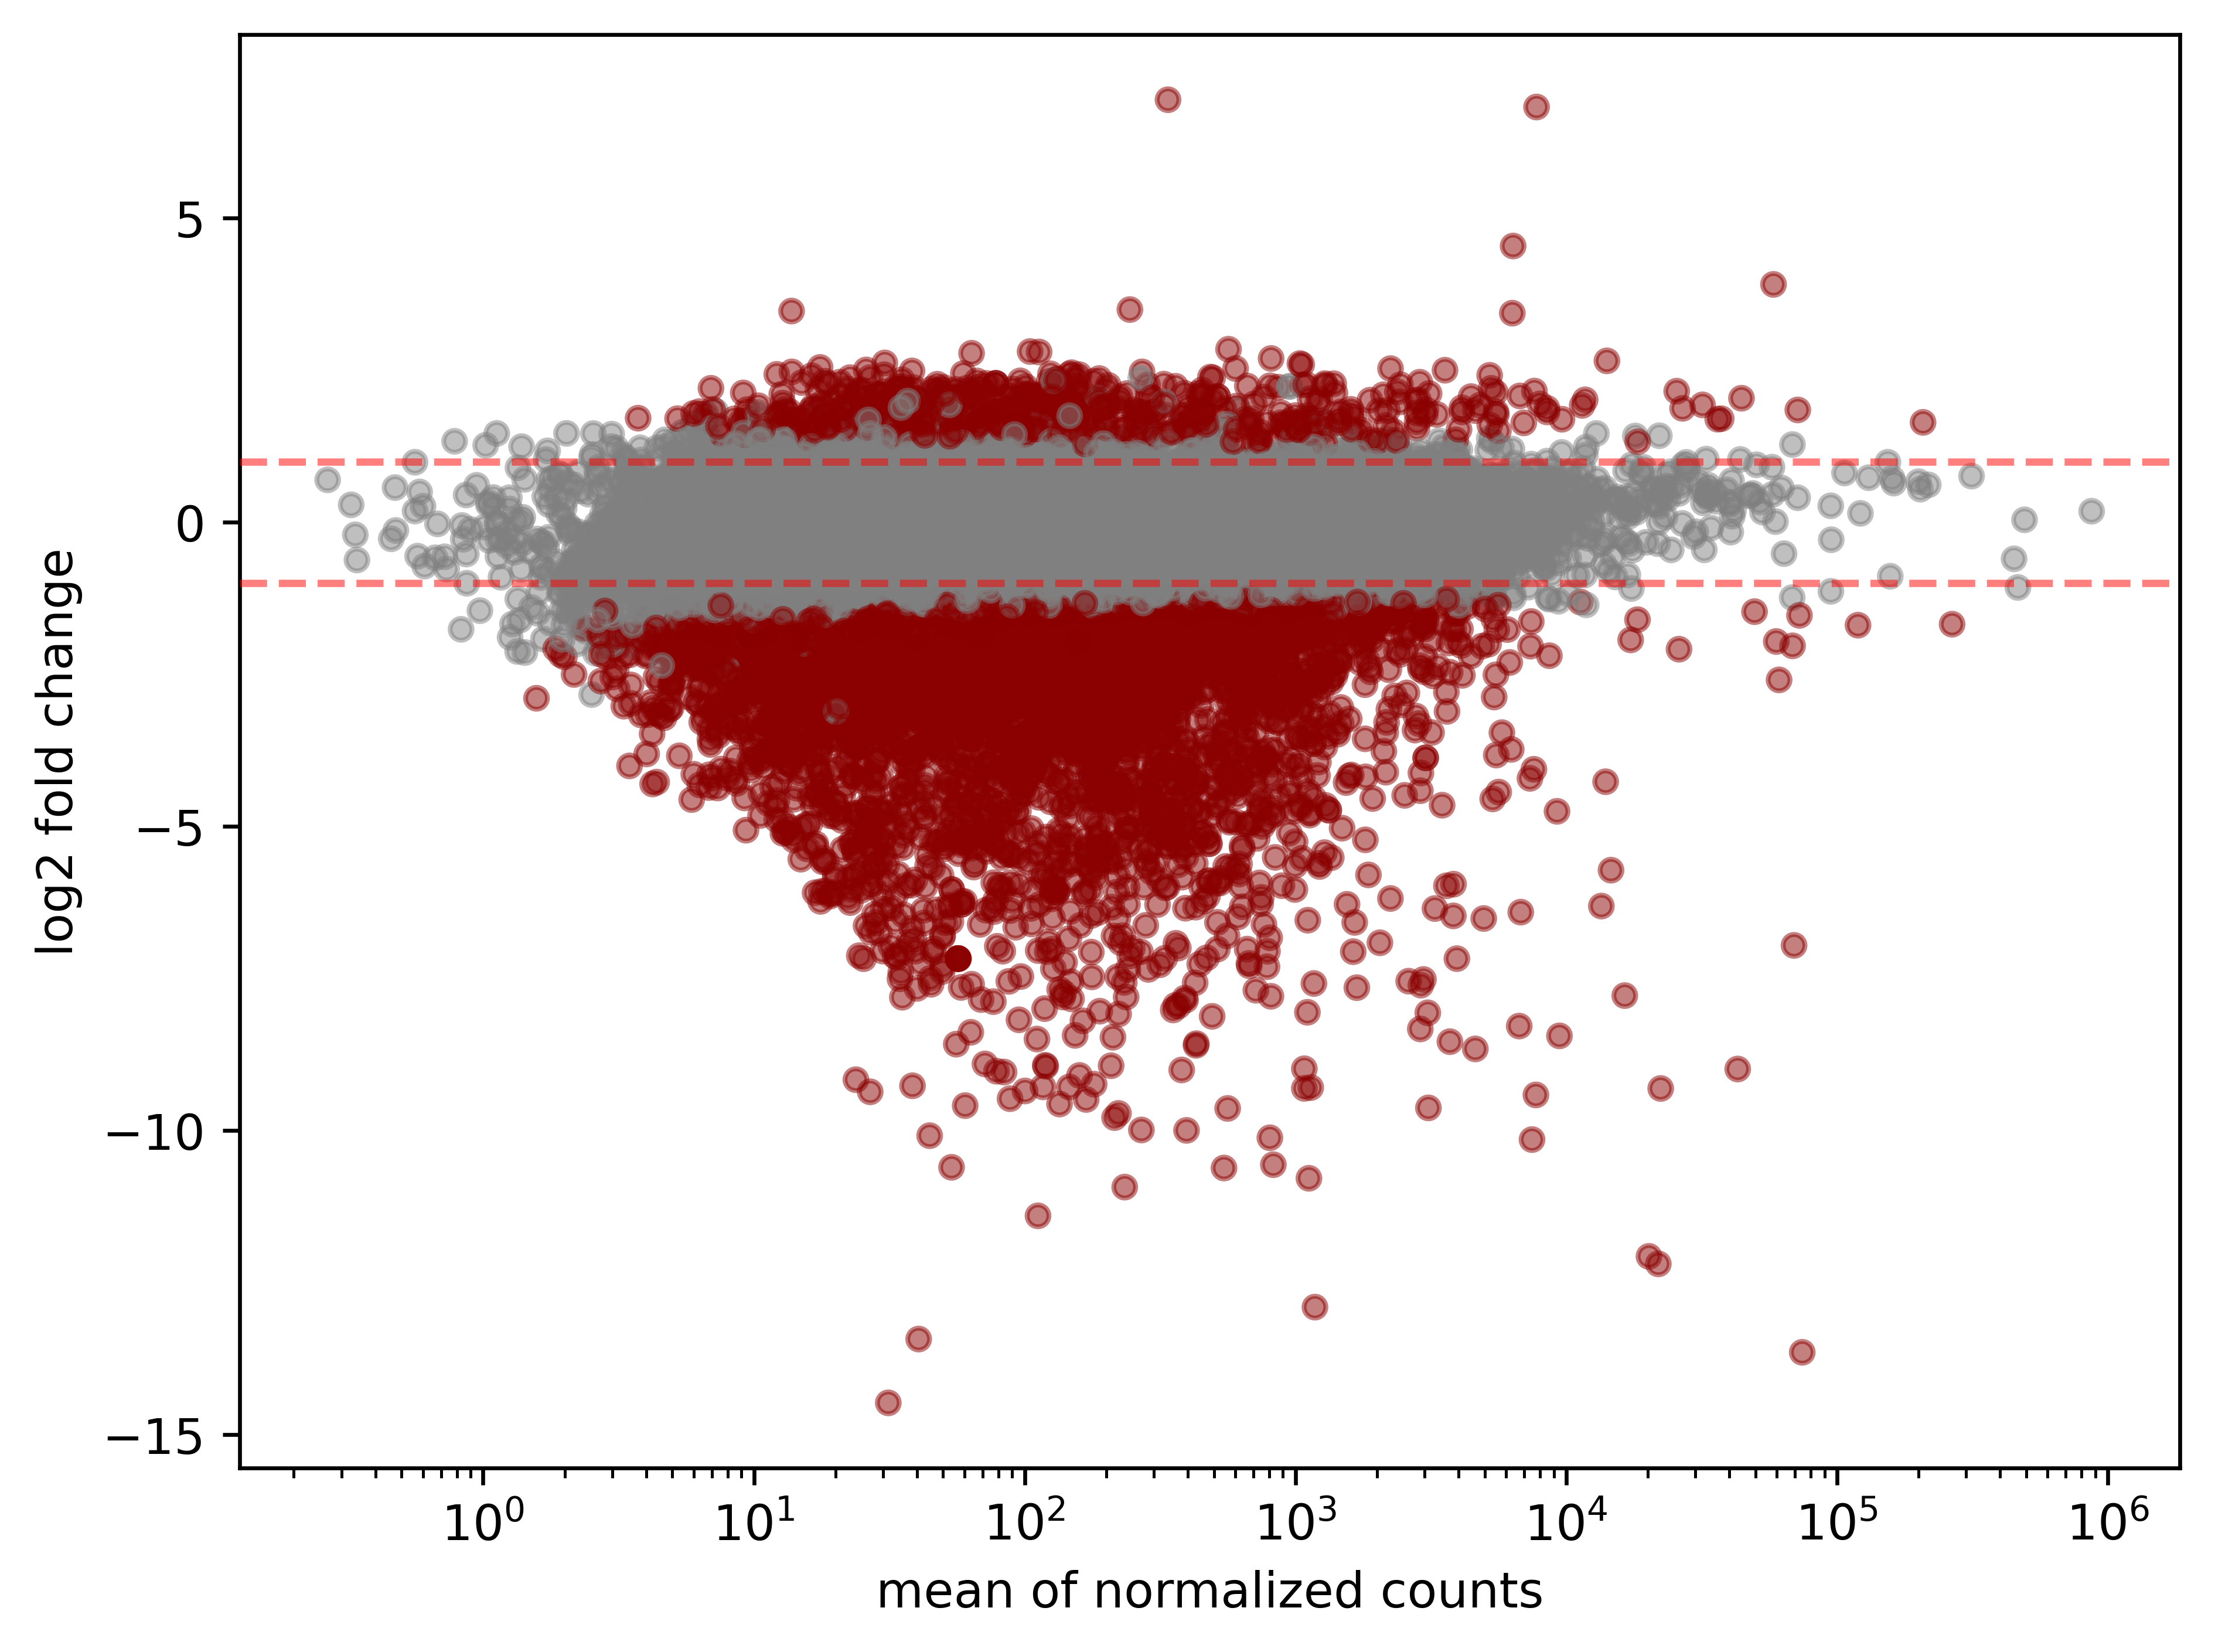

In [5]:
#look for log fold changes sig greater than 1
LFC1_res = DGE_res.summary(lfc_null=1.0, alt_hypothesis="greaterAbs")
DGE_res.plot_MA(s=20)

In [13]:
de = DGE_res.results_df
de['logP'] = (np.log10(de['padj'])) * -1

/home/alexanderb/miniconda3/envs/DGE_env/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


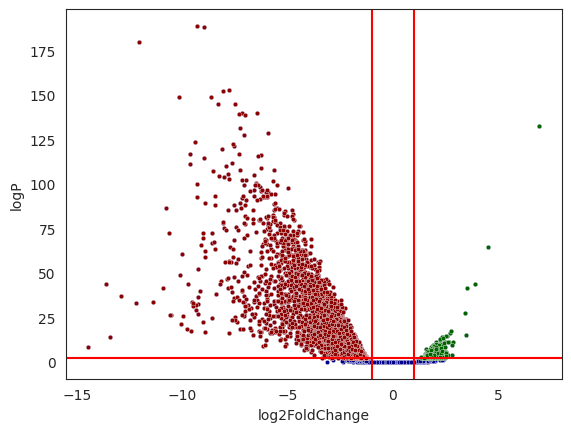

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(ncols = 1)
sns.set_style('white')

sns.scatterplot(data = de, x = 'log2FoldChange', y = 'logP', ax=ax, s = 10, color = 'darkblue')
sns.despine
plt.axvline(-1, color = 'red')
plt.axvline(1, color = 'red')
plt.axhline(np.log10(0.01) * -1, color = 'red')

sns.scatterplot(data = de[((de['log2FoldChange'] < - 1)) & ((de['padj'] < 0.01))], x = 'log2FoldChange', y = 'logP', ax=ax, s = 10, color = 'darkred')
sns.scatterplot(data = de[((de['log2FoldChange'] > 1)) & ((de['padj'] < 0.01))], x = 'log2FoldChange', y = 'logP', ax=ax, s = 10, color = 'darkgreen')

plt.savefig('./figures/Male_Female_volcano', bbox_inches = 'tight', dpi = 300)

In [7]:
sig_DEG = de[de['padj'] < 0.01]
sig_2LFC = sig_DEG[abs(sig_DEG['log2FoldChange']) > 2 ]

In [33]:
sig_2LFC

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
AADACL3,16.416584,-2.597549,0.261335,-6.113038,9.775226e-10,1.019053e-08
AATBC,38.895935,-2.792847,0.175931,-10.190633,2.183368e-24,5.198137e-23
AATK,689.306320,-2.718907,0.156600,-10.976433,4.961310e-28,1.375834e-26
ABCA17P,25.209467,-3.278415,0.211322,-10.781747,4.198340e-27,1.114178e-25
ABCA3,469.880258,-2.015424,0.139943,-7.255996,3.987171e-13,5.321679e-12
...,...,...,...,...,...,...
ZNNT1,121.693764,-2.316901,0.161704,-8.143890,3.827780e-16,6.039817e-15
ZRSR2P1,100.776286,2.231987,0.336293,3.663429,2.488610e-04,1.460955e-03
ZSCAN1,17.412365,-3.446826,0.293619,-8.333339,7.859373e-17,1.293172e-15
ZSCAN18,519.013801,-2.206346,0.131689,-9.160539,5.163898e-20,9.976462e-19
